# FEA increase positions and individual trajectories

This notebook reads the three local EmoHeVRDB-DFEA CSVs, selects the highest-mean coefficient for each non-Neutral category, and creates only the largest-increase heatmap and six individual-trajectory figures with category means. Run all cells in order. Dependencies: NumPy, pandas, Matplotlib, and IPython.

No datasets or figure outputs are embedded in the distributed notebook. Seven separate PDFs are exported to `EXPORT_DIR`. Category names belong in the LaTeX subcaptions; each trajectory figure retains its coefficient name and sample count in the title.

## 1. Configuration
The heatmap settings preserve the supplied viridis appearance. Trajectory settings preserve the supplied colors, line styles, and axis limits. Adjust figure sizes and fonts here for the final LaTeX layout.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from IPython.display import display

DATA_DIR = Path("/workspace/datasets/emoji-hero-vr-db-dfea-as-csv")
EXPORT_DIR = Path("figures/fea_temporal_analysis")
EXPORT_DPI = 300  # Resolution of rasterized background trajectories in PDFs.
SPLIT_FILES = {"train": "training_set.csv", "validation": "validation_set.csv", "test": "test_set.csv"}
LABEL_NAMES = dict(enumerate(["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]))
CATEGORIES = [name for name in LABEL_NAMES.values() if name != "Neutral"]
STEPS = np.arange(1, 31)
POSITIONS = np.arange(2, 31)  # Destination steps of consecutive increases.

In [2]:
def export_pdf(fig, filename):
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    path = EXPORT_DIR / filename
    fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight", pad_inches=.02)
    return path

## 2. Load and select coefficients

All retained training, validation, and test sequences are pooled for this descriptive analysis. For each of the 63 coefficients, first average its 30 observations within each sequence, then average these sequence means within each category. Select the coefficient with the highest category mean (alphabetical tie-breaking). Coefficients are not standardized. Neutral is omitted from the plots.

In [3]:
frames = []
for split, filename in SPLIT_FILES.items():
    path = DATA_DIR / filename
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}. Set DATA_DIR to the directory containing all three CSVs.")
    frames.append(pd.read_csv(path).assign(split=split))
raw = pd.concat(frames, ignore_index=True)
channels = [name for name in raw.columns if name not in {"sequence_id", "timestamp", "Label", "split"}]
assert len(channels) == 63, "Expected 63 FEA coefficients."
assert raw[["sequence_id", "timestamp", "Label"]].notna().all().all()
assert np.isfinite(raw[channels].to_numpy()).all(), "Coefficients must be finite."
assert not raw.duplicated(["sequence_id", "timestamp"]).any()
raw["Category"] = raw["Label"].map(LABEL_NAMES)
assert raw["Category"].notna().all(), "Unknown label."
raw = raw.sort_values(["sequence_id", "timestamp"]).reset_index(drop=True)
groups = raw.groupby("sequence_id", sort=False)
assert groups.size().eq(30).all(), "Each sequence must have 30 observations."
assert groups["Category"].nunique().eq(1).all()
assert groups["split"].nunique().eq(1).all(), "Sequence appears in multiple splits."
raw["timestep"] = groups.cumcount() + 1

sequence_means = raw.groupby(["sequence_id", "Category"])[channels].mean().reset_index()
category_means = sequence_means.groupby("Category")[channels].mean()
selected_channels, matrices = {}, {}
for category in CATEGORIES:
    profile = category_means.loc[category]
    channel = sorted(profile.index[profile.eq(profile.max())])[0]
    selected_channels[category] = channel
    matrices[category] = raw.loc[raw.Category.eq(category)].pivot(
        index="sequence_id", columns="timestep", values=channel
    ).reindex(columns=STEPS)

coverage = pd.crosstab(raw.drop_duplicates("sequence_id")["Category"],
                       raw.drop_duplicates("sequence_id")["split"])
display(coverage.reindex(list(LABEL_NAMES.values())))
print(f"Loaded {raw.sequence_id.nunique():,} sequences, including Neutral.")

split,test,train,validation
Category,,,
Anger,54,66,55
Disgust,54,102,55
Fear,54,105,55
Happiness,54,191,55
Neutral,54,197,55
Sadness,54,131,55
Surprise,54,172,55


Loaded 1,727 sequences, including Neutral.


## 3. Largest-increase positions

Each sequence with a strictly positive increase contributes one event: the destination step of its largest consecutive increase. Exact ties use the earliest step. Sequences without an increase are excluded from the heatmap denominator, but remain in the trajectory plots. Each row is normalized by its own eligible-sequence count.

For each category, scan all intervals of `HEATMAP_STYLE['interval_width']` consecutive positions. Outline the earliest interval attaining the maximum count. These positions describe coefficient transitions, not annotated expression phases.

In [4]:
HEATMAP_STYLE = dict(
    figsize=(12.8, 3.2),
    figure_dpi=110,
    font_family='DejaVu Sans',
    facecolor='white',

    # Colors.
    cmap='viridis',
    color_max=10,            # None uses the largest cell percentage.
    end_color=None,          # Optional custom upper-end color.

    # Cell annotations.
    show_counts=True,
    show_percentages=False,
    count_fontsize=10,
    count_weight='normal',
    percent_fontsize=7,
    percent_weight='normal',
    percent_decimals=1,
    count_y=.35,             # Used when both annotation types are shown.
    percent_y=.70,

    # Cell borders.
    linewidths=.5,
    linecolor='white',

    # Highlight the earliest most populated interval of this width.
    show_intervals=True,
    interval_width=10,       # Any integer from 1 to 29; recomputed below.
    interval_color='#202020',
    interval_linewidth=1.5,
    interval_linestyle='-',
    interval_halo=True,
    interval_halo_color='white',
    interval_halo_width=1.5,

    # Row labels: category, selected coefficient, and denominator.
    show_channels=True,
    show_n=True,

    # Tick labels.
    x_tick_fontsize=9,
    y_tick_fontsize=9,
    tick_weight='normal',
    tick_pad=7,
    x_tick_every=1,

    # Titles and axis labels.
    title='',                # Standalone option: 'Largest-increase positions'
    title_fontsize=13,
    title_weight='bold',
    title_align='left',
    title_pad=13,
    xlabel='Time step',
    ylabel='',
    label_fontsize=10,
    label_weight='bold',
    label_pad=9,

    # Colorbar.
    show_colorbar=True,
    colorbar_label='Within-category share (%)',
    colorbar_fontsize=9,
    colorbar_tick_fontsize=8,
    colorbar_fraction=.035,
    colorbar_pad=.02,
    colorbar_tick_step=1,     # None selects ticks automatically.

    # Keep explanatory notes in the LaTeX caption for the paper.
    show_note=False,
    note_fontsize=9,
)

In [5]:
width = HEATMAP_STYLE["interval_width"]
if not isinstance(width, (int, np.integer)) or not 1 <= width <= 29:
    raise ValueError("interval_width must be an integer from 1 to 29.")
counts = pd.DataFrame(0, index=CATEGORIES, columns=POSITIONS)
summary_rows = []
for category in CATEGORIES:
    values = matrices[category].to_numpy()
    changes = np.diff(values, axis=1)
    eligible = changes.max(axis=1) > 0
    positions = changes[eligible].argmax(axis=1) + 2  # np.argmax returns the first maximum.
    if len(positions) == 0:
        raise ValueError(f"No positive increases for {category}.")
    counts.loc[category] = np.bincount(positions, minlength=31)[2:31]
    window_counts = np.convolve(counts.loc[category].to_numpy(), np.ones(width, dtype=int), mode="valid")
    best_start = int(POSITIONS[window_counts.argmax()])
    maximum = int(window_counts.max())
    summary_rows.append({
        "Category": category, "Channel": selected_channels[category], "Width": width,
        "N all": len(values), "N positive": len(positions), "N without increase": int((~eligible).sum()),
        "First best start": best_start, "First best end": best_start + width - 1,
        "Max count": maximum, "Max share (%)": 100 * maximum / len(positions),
    })
intervals = pd.DataFrame(summary_rows)
denominators = intervals.set_index("Category")["N positive"]
percentages = counts.div(denominators, axis=0) * 100
assert np.array_equal(counts.sum(axis=1), denominators.reindex(CATEGORIES))
assert np.allclose(percentages.sum(axis=1), 100)
display(intervals.round(2))

,Category,Channel,Width,N all,N positive,N without increase,First best start,First best end,Max count,Max share (%)
0,Anger,BrowLowererL,10,175,174,1,18,27,71,40.80
1,Disgust,NoseWrinklerR,10,211,198,13,13,22,78,39.39
2,Fear,UpperLidRaiserR,10,214,168,46,4,13,65,38.69
3,Happiness,LipCornerPullerR,10,300,295,5,14,23,129,43.73
4,Sadness,LipCornerDepressorL,10,240,240,0,9,18,115,47.92
5,Surprise,JawDrop,10,281,281,0,2,11,124,44.13


## 4. Viridis heatmap
The plotting helper below preserves the supplied heatmap appearance and configurable style parameters. Counts are annotated in the cells; colors encode within-category percentages. Explain these encodings and the interval outline in the LaTeX caption.

In [6]:
def plot_largest_increase_heatmap(
    counts, percentages, intervals, denominators,
    *,
    figsize=(16, 4),
    figure_dpi=110,
    font_family='DejaVu Sans',
    facecolor='white',
    cmap='Blues',
    color_max=10,
    end_color=None,
    show_counts=True,
    show_percentages=False,
    count_fontsize=10,
    count_weight='normal',
    percent_fontsize=7,
    percent_weight='normal',
    percent_decimals=1,
    count_y=.35,
    percent_y=.70,
    linewidths=.5,
    linecolor='white',
    show_intervals=True,
    interval_width=10,
    interval_color='#202020',
    interval_linewidth=2,
    interval_linestyle='-',
    interval_halo=True,
    interval_halo_color='white',
    interval_halo_width=2,
    show_channels=True,
    show_n=True,
    x_tick_fontsize=9,
    y_tick_fontsize=9,
    tick_weight='normal',
    tick_pad=7,
    x_tick_every=1,
    title='',
    title_fontsize=13,
    title_weight='bold',
    title_align='left',
    title_pad=13,
    xlabel='Time step',
    ylabel='',
    label_fontsize=10,
    label_weight='normal',
    label_pad=9,
    show_colorbar=True,
    colorbar_label='Within-category share (%)',
    colorbar_fontsize=9,
    colorbar_tick_fontsize=8,
    colorbar_fraction=.035,
    colorbar_pad=.02,
    colorbar_tick_step=1,
    show_note=False,
    note_fontsize=9,
):
    """Plot counts annotated over within-category percentage colors.

    Each row refers to one category and its selected coefficient.
    Denominators must match the event-bearing sequences used in that row.
    Interval summaries must come from the same events.

    The function changes only presentation and returns a Figure.
    """

    # Validate matrices and normalization.
    if (
        not counts.index.equals(percentages.index)
        or not counts.columns.equals(percentages.columns)
    ):
        raise ValueError(
            'Count and percentage matrices must have identical labels.'
        )

    count_values = counts.to_numpy(dtype=float)
    percentage_values = percentages.to_numpy(dtype=float)
    denominator_values = (
        denominators.reindex(counts.index).to_numpy(dtype=float)
    )

    if not np.isfinite(count_values).all() or (count_values < 0).any():
        raise ValueError('Counts must be finite and nonnegative.')
    if not np.allclose(count_values, np.round(count_values)):
        raise ValueError('Counts must be integers.')
    if (
        not np.isfinite(percentage_values).all()
        or (percentage_values < 0).any()
    ):
        raise ValueError('Percentages must be finite and nonnegative.')
    if (
        not np.isfinite(denominator_values).all()
        or (denominator_values <= 0).any()
    ):
        raise ValueError('Every denominator must be finite and positive.')
    if not np.allclose(count_values.sum(axis=1), denominator_values):
        raise ValueError(
            'Counts must sum to the supplied event-bearing denominators.'
        )
    if not np.allclose(
        percentage_values,
        100 * count_values / denominator_values[:, None],
    ):
        raise ValueError(
            'Percentages must equal counts divided by row denominators.'
        )

    positions = np.asarray(counts.columns, dtype=int)
    nrows, ncols = counts.shape

    if (
        not np.array_equal(positions, counts.columns.to_numpy())
        or not np.all(np.diff(positions) == 1)
    ):
        raise ValueError(
            'Position columns must be consecutive, increasing integers.'
        )

    maximum_percentage = float(percentage_values.max())
    vmax = (
        maximum_percentage
        if color_max is None
        else float(color_max)
    )
    if not np.isfinite(vmax) or vmax <= 0 or vmax < maximum_percentage:
        raise ValueError('color_max must cover every cell percentage.')

    if not isinstance(x_tick_every, (int, np.integer)) or x_tick_every < 1:
        raise ValueError('x_tick_every must be a positive integer.')
    if show_intervals and (
        not isinstance(interval_width, (int, np.integer))
        or not 1 <= interval_width <= ncols
    ):
        raise ValueError(
            'interval_width must be an integer between 1 and '
            'the number of position columns.'
        )
    if colorbar_tick_step is not None and colorbar_tick_step <= 0:
        raise ValueError('colorbar_tick_step must be positive or None.')
    if not 0 <= count_y <= 1 or not 0 <= percent_y <= 1:
        raise ValueError('Annotation positions must be between 0 and 1.')

    # Prepare the colormap.
    cm = plt.get_cmap(cmap)
    if end_color is not None:
        stops = [(x * .88, cm(x)) for x in np.linspace(0, 1, 12)]
        cm = LinearSegmentedColormap.from_list(
            'extended_heatmap',
            stops + [(1, end_color)],
        )

    with plt.rc_context({
        'font.family': font_family,
        'figure.dpi': figure_dpi,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
    }):
        fig, ax = plt.subplots(
            figsize=figsize,
            layout='constrained',
            facecolor=facecolor,
        )
        ax.set_facecolor(facecolor)

        im = ax.imshow(
            percentage_values,
            cmap=cm,
            vmin=0,
            vmax=vmax,
            aspect='auto',
            interpolation='nearest',
        )

        row_labels = []

        for i, category in enumerate(counts.index):
            category_intervals = intervals.loc[
                intervals['Category'].eq(category)
            ]

            # Category/coefficient labels do not depend on the chosen width.
            label = str(category)
            if show_channels:
                channels = category_intervals['Channel'].dropna().unique()
                if len(channels) != 1:
                    raise ValueError(
                        f'Expected one selected coefficient for {category}; '
                        f'found {len(channels)}.'
                    )
                label += f' · {channels[0]}'
            if show_n:
                label += f'\n(n = {int(denominator_values[i])})'
            row_labels.append(label)

            # Outline the earliest maximum-concentration interval.
            if show_intervals:
                matches = category_intervals.loc[
                    category_intervals['Width'].eq(interval_width)
                ]
                if len(matches) != 1:
                    raise ValueError(
                        f'Expected one interval summary for {category}, '
                        f'width={interval_width}; found {len(matches)}. '
                        'Include this width when calling scan_intervals().'
                    )
                best = matches.iloc[0]
                start = int(best['First best start'])
                end = int(best['First best end'])

                if end - start + 1 != interval_width:
                    raise ValueError(
                        f'Interval width does not match its endpoints '
                        f'for {category}.'
                    )
                if start not in positions or end not in positions:
                    raise ValueError(
                        f'Interval endpoints are outside the heatmap '
                        f'for {category}.'
                    )
                if not np.isclose(
                    counts.loc[category, start:end].sum(),
                    best['Max count'],
                ):
                    raise ValueError(
                        f'Interval count does not match the heatmap '
                        f'for {category}.'
                    )

                start_col = int(np.flatnonzero(positions == start)[0])
                end_col = int(np.flatnonzero(positions == end)[0])

                outline = Rectangle(
                    (start_col - .5, i - .46),
                    end_col - start_col + 1,
                    .92,
                    fill=False,
                    edgecolor=interval_color,
                    linewidth=interval_linewidth,
                    linestyle=interval_linestyle,
                    zorder=4,
                )
                if interval_halo:
                    outline.set_path_effects([
                        path_effects.Stroke(
                            linewidth=(
                                interval_linewidth + interval_halo_width
                            ),
                            foreground=interval_halo_color,
                        ),
                        path_effects.Normal(),
                    ])
                ax.add_patch(outline)

            # Annotate cells with counts and/or percentages.
            for j, position in enumerate(positions):
                value = float(percentages.loc[category, position])

                # Select text color from the actual cell background.
                rgb = np.asarray(im.cmap(im.norm(value))[:3])
                linear = np.where(
                    rgb <= .04045,
                    rgb / 12.92,
                    ((rgb + .055) / 1.055) ** 2.4,
                )
                luminance = float(linear @ [0.2126, .7152, .0722])
                text_color = 'white' if luminance < .179 else 'black'
                both = show_counts and show_percentages

                if show_counts:
                    ax.text(
                        j,
                        i - .5 + count_y if both else i,
                        str(int(counts.loc[category, position])),
                        ha='center',
                        va='center',
                        fontsize=count_fontsize,
                        fontweight=count_weight,
                        color=text_color,
                    )

                if show_percentages:
                    ax.text(
                        j,
                        i - .5 + percent_y if both else i,
                        f'{value:.{percent_decimals}f}%',
                        ha='center',
                        va='center',
                        fontsize=percent_fontsize,
                        fontweight=percent_weight,
                        color=text_color,
                    )

        # Tick labels.
        ticks = sorted(
            set(range(0, ncols, x_tick_every)) | {ncols - 1}
        )
        ax.set_xticks(
            ticks,
            labels=positions[ticks],
            fontsize=x_tick_fontsize,
            fontweight=tick_weight,
        )
        ax.set_yticks(
            np.arange(nrows),
            labels=row_labels,
            fontsize=y_tick_fontsize,
            fontweight=tick_weight,
        )
        ax.tick_params(axis='both', length=0, pad=tick_pad)

        # Keep category/coefficient labels on the left.
        ax.tick_params(
            axis='y',
            labelleft=True,
            labelright=False,
            left=False,
            right=False,
        )
        ax.yaxis.set_label_position('left')
        for tick_label in ax.get_yticklabels():
            tick_label.set_horizontalalignment('right')
            tick_label.set_multialignment('right')

        # Cell borders and axes.
        ax.grid(False, which='both')
        if linewidths > 0:
            ax.set_xticks(np.arange(-.5, ncols, 1), minor=True)
            ax.set_yticks(np.arange(-.5, nrows, 1), minor=True)
            ax.grid(
                which='minor',
                color=linecolor,
                linewidth=linewidths,
            )
        ax.tick_params(
            which='minor',
            bottom=False,
            top=False,
            left=False,
            right=False,
        )
        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_xlabel(
            xlabel,
            fontsize=label_fontsize,
            fontweight=label_weight,
            labelpad=label_pad,
        )
        ax.set_ylabel(
            ylabel,
            fontsize=label_fontsize,
            fontweight=label_weight,
            labelpad=label_pad,
            rotation=90,
        )
        if title:
            ax.set_title(
                title,
                loc=title_align,
                pad=title_pad,
                fontsize=title_fontsize,
                fontweight=title_weight,
            )

        # Colorbar stays on the right.
        if show_colorbar:
            cbar = fig.colorbar(
                im,
                ax=ax,
                fraction=colorbar_fraction,
                pad=colorbar_pad,
            )
            cbar.set_label(
                colorbar_label,
                fontsize=colorbar_fontsize,
            )
            cbar.ax.tick_params(labelsize=colorbar_tick_fontsize)
            if colorbar_tick_step is not None:
                cbar.set_ticks(
                    np.arange(0, vmax + 1e-9, colorbar_tick_step)
                )

        # Optional standalone note; disabled for the paper.
        if show_note:
            notes = []
            if show_counts:
                notes.append('Cell numbers: sequence counts')
            if show_percentages:
                notes.append(
                    'Cell percentages: within-category shares'
                )
            if show_intervals:
                notes.append(
                    f'Outline: most populated {interval_width}-step '
                    'interval (earliest if tied)'
                )
            if notes:
                fig.supxlabel(
                    '  |  '.join(notes),
                    fontsize=note_fontsize,
                )

    return fig


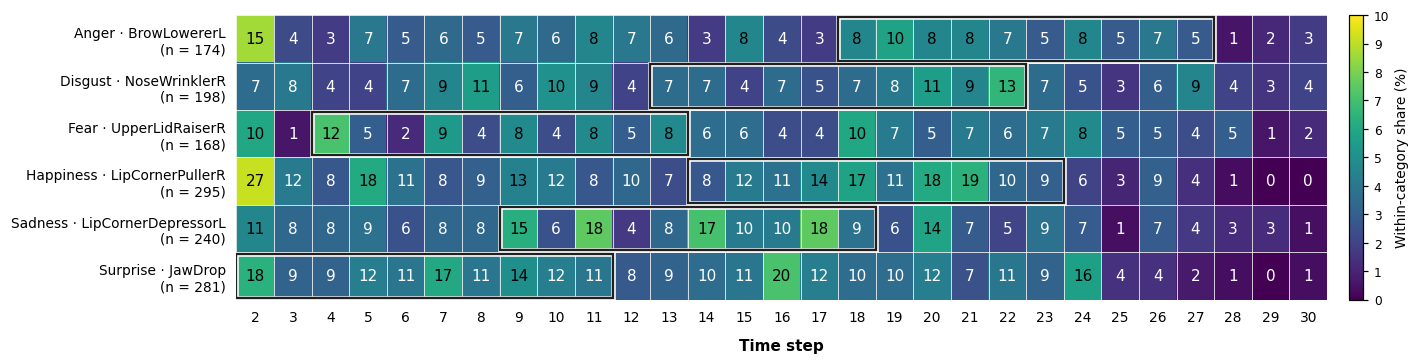

In [7]:
fig_heatmap = plot_largest_increase_heatmap(counts, percentages, intervals, denominators, **HEATMAP_STYLE)
exported_paths = [export_pdf(fig_heatmap, "largest_increase_heatmap.pdf")]
plt.show()
plt.close(fig_heatmap)

## 5. Individual trajectories and category means

Every sequence is drawn as a thin, translucent line; the thick line is the arithmetic mean at each time step. Flat sequences are included. There is no smoothing, phase alignment, or participant balancing. Each category uses its own selected coefficient, so absolute levels should not be interpreted as comparable expression intensities.

The six PDFs retain the coefficient name and total sequence count in their titles. Use only the category name in each LaTeX subcaption. Note that these total counts can exceed the heatmap's positive-increase denominators.

In [8]:
TRAJECTORY_STYLE = dict(
    figsize=(6, 4.5), 
    figure_dpi=120, 
    font_family="DejaVu Sans", 
    font_size=14,
    mean_linewidth=3.0, 
    mean_halo_width=2.5, 
    sample_linewidth=0.7, 
    sample_alpha=0.12,
    ylim=(0, 1.02), 
    xlabel="Time step", 
    ylabel="Coefficient value",
    title_template="{channel} · n={n}", 
    title_fontsize=14,
    legend_fontsize=9, 
    grid_alpha=.15,
    colors=["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#6F4C9B"],
)


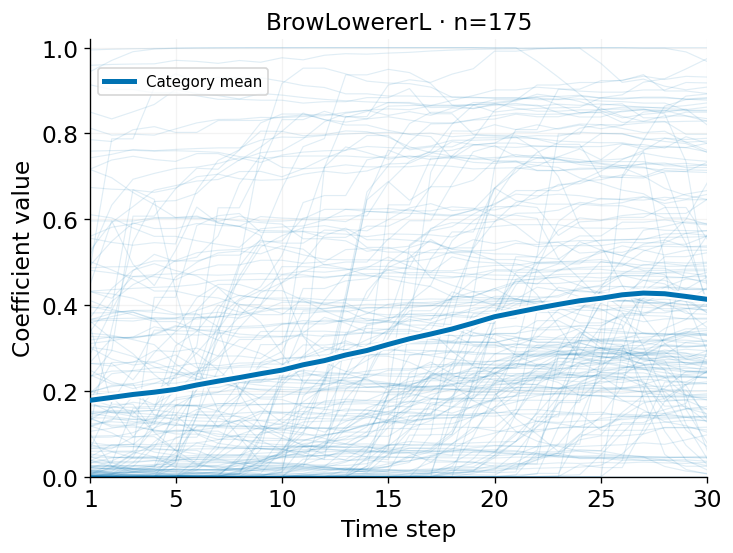

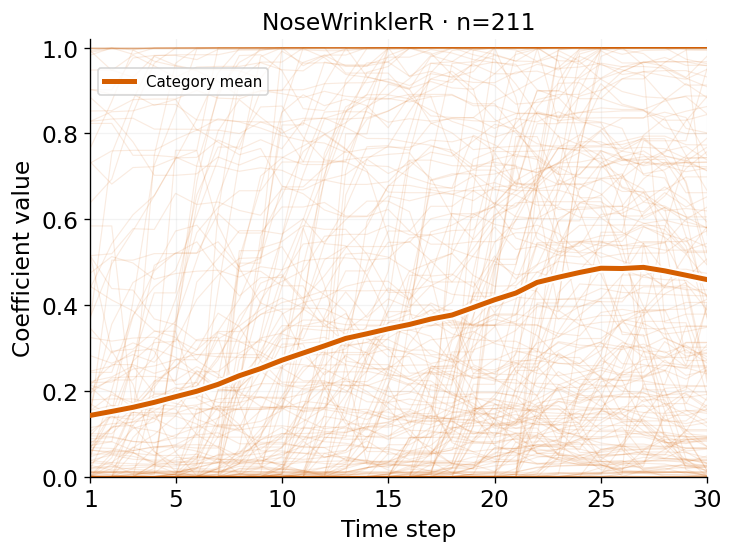

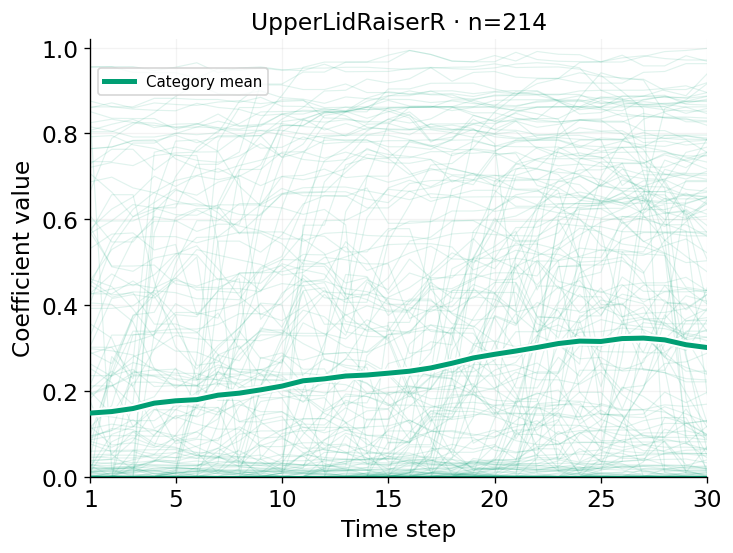

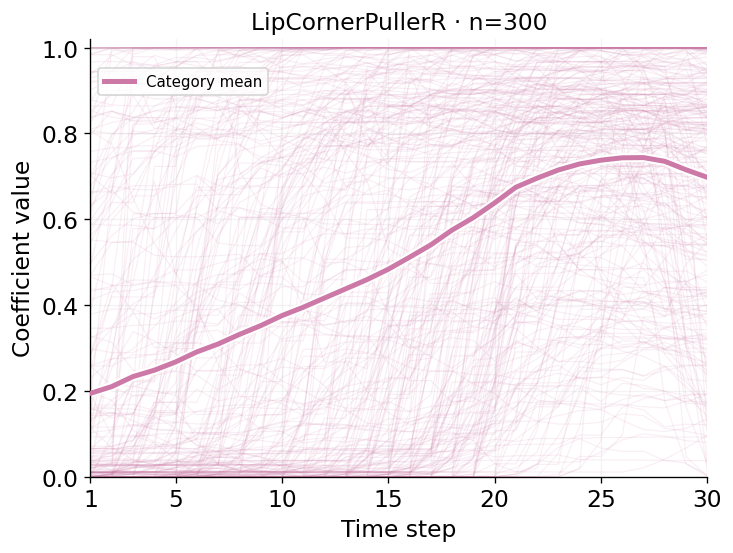

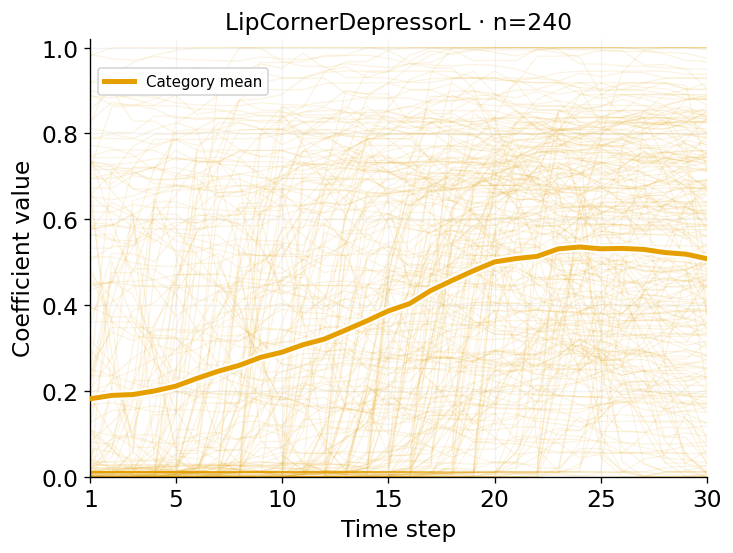

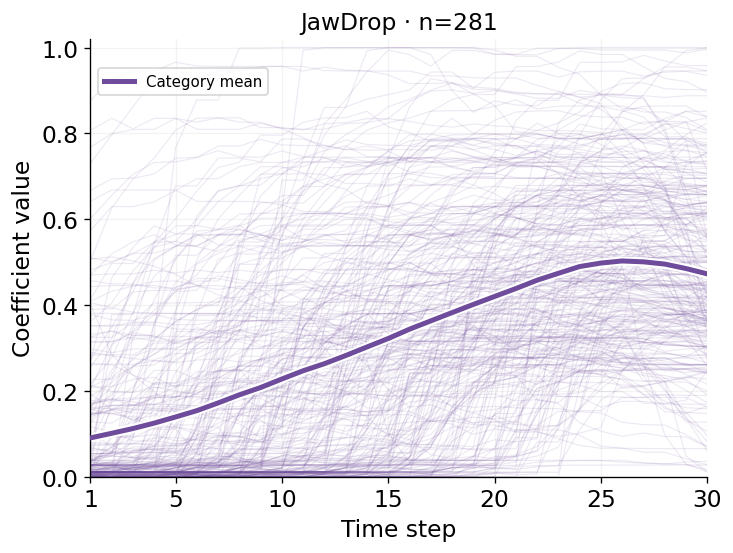

In [9]:
def plot_trajectories(category, color, style):
    values = matrices[category].to_numpy()
    with plt.rc_context({
        "font.family": style["font_family"], "font.size": style["font_size"],
        "figure.dpi": style["figure_dpi"], "pdf.fonttype": 42,
        "axes.spines.top": False, "axes.spines.right": False,
    }):
        fig, ax = plt.subplots(figsize=style["figsize"], layout="constrained")
        ax.plot(STEPS, values.T, color=color, alpha=style["sample_alpha"],
                linewidth=style["sample_linewidth"], rasterized=True, zorder=1)
        mean = values.mean(axis=0)
        ax.plot(STEPS, mean, color="white", linewidth=style["mean_linewidth"] + style["mean_halo_width"], zorder=2)
        ax.plot(STEPS, mean, color=color, linewidth=style["mean_linewidth"], label="Category mean", zorder=3)
        ax.set(xlim=(1, 30), ylim=style["ylim"], xlabel=style["xlabel"], ylabel=style["ylabel"])
        ax.set_title(style["title_template"].format(channel=selected_channels[category], n=len(values), category=category),
                     fontsize=style["title_fontsize"])
        ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
        ax.grid(alpha=style["grid_alpha"])
        ax.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=style["legend_fontsize"])
    return fig


assert len(TRAJECTORY_STYLE["colors"]) == len(CATEGORIES)
for category, color in zip(CATEGORIES, TRAJECTORY_STYLE["colors"]):
    fig = plot_trajectories(category, color, TRAJECTORY_STYLE)
    exported_paths.append(export_pdf(fig, f"trajectories_{category.lower()}.pdf"))
    plt.show()
    plt.close(fig)


In [10]:
print("Exported seven PDFs:")
for path in exported_paths:
    print(path.resolve())

Exported seven PDFs:
/workspace/repos/emohevrdb-dfer/6_discussion/6_1_temporal_modeling_for_FER_under_HMD_occlusion/figures/fea_temporal_analysis/largest_increase_heatmap.pdf
/workspace/repos/emohevrdb-dfer/6_discussion/6_1_temporal_modeling_for_FER_under_HMD_occlusion/figures/fea_temporal_analysis/trajectories_anger.pdf
/workspace/repos/emohevrdb-dfer/6_discussion/6_1_temporal_modeling_for_FER_under_HMD_occlusion/figures/fea_temporal_analysis/trajectories_disgust.pdf
/workspace/repos/emohevrdb-dfer/6_discussion/6_1_temporal_modeling_for_FER_under_HMD_occlusion/figures/fea_temporal_analysis/trajectories_fear.pdf
/workspace/repos/emohevrdb-dfer/6_discussion/6_1_temporal_modeling_for_FER_under_HMD_occlusion/figures/fea_temporal_analysis/trajectories_happiness.pdf
/workspace/repos/emohevrdb-dfer/6_discussion/6_1_temporal_modeling_for_FER_under_HMD_occlusion/figures/fea_temporal_analysis/trajectories_sadness.pdf
/workspace/repos/emohevrdb-dfer/6_discussion/6_1_temporal_modeling_for_FER_und

## LaTeX placement

Arrange `trajectories_anger.pdf`, `trajectories_disgust.pdf`, `trajectories_fear.pdf`, `trajectories_happiness.pdf`, `trajectories_sadness.pdf`, and `trajectories_surprise.pdf` in the desired grid inside a double-column figure. Use the corresponding category names as subcaptions. Export the heatmap as a separate figure. Check label sizes after scaling to the final panel width; `TRAJECTORY_STYLE` controls the source dimensions and fonts.